In [1]:
%cd ../.
import os, sys
sys.path.insert(0, os.path.abspath('../Scripts'))
sys.path.insert(0, os.path.expanduser('~/CDD_Vault_API/python'))  # CDD Vault API (get_df)

/home/gtamo/ADME_ML


In [2]:
%load_ext autoreload
%autoreload 2

import re
import os
import pandas as pd
import numpy as np
import py3Dmol
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap
import csv
import pickle

from pathlib import Path
from rdkit import Chem
from rdkit.Chem import AllChem,rdFMCS
# import prolif as plf
from glob import glob
import meeko
import subprocess as sub
# from vina import Vina
import time
from tqdm import tqdm
tqdm.pandas()
import importlib
from sklearn.ensemble import RandomForestClassifier, RandomForestRegressor, HistGradientBoostingClassifier
from sklearn.dummy import DummyClassifier
from sklearn.manifold import TSNE
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.model_selection import StratifiedKFold, cross_val_predict, KFold
from sklearn.metrics import f1_score, silhouette_score, davies_bouldin_score, calinski_harabasz_score
from sklearn.metrics import roc_auc_score, average_precision_score, matthews_corrcoef
from xgboost import XGBClassifier,XGBRegressor
from openTSNE import TSNE as oTSNE        # pip install openTSNE
import seaborn as sns
from scipy import stats
import csv, contextlib, threading, joblib
import joblib
from joblib import Parallel, delayed
from datetime import date
## load internal (in-house) + public-augmented data, champion model, eval helpers
from copy import deepcopy



# user defined modules
import Rdkit_tools as rdkit_tools
importlib.reload(rdkit_tools)
import Molecule as M
import ML_Reg as ML_Reg
import ML_Class as ML_Class
from MolViz3D import MolViz3D
import Statistics_tools as stats_tools
import python.functions as fn
from python.harmonize_sol import harmonize_solubility

from get_library import get_df   # CDD Vault collection export
from get_protocol_data import get_data, load_config, alias_map
# from tdc.multi_pred import DTI

> could not load openbabel


In [ ]:
## plot RMSEs:  (RMSE in each endpoint's modelling units — comparable across models within an endpoint, not across endpoints)
import yaml
palette = yaml.safe_load(open('config/config.yaml'))['SERAC_C']
res = pd.read_csv('output/predictions_runs/summary_best_r2_rmse.csv')

groups = [('RFint_rmse', 'Internal-only', palette['paper']),   # RF, internal compounds only
          ('RFaug_rmse', 'RF augmented', palette['ember']),    # RF, internal + public
          ('CP_rmse',    'Chemprop',     palette['azure'])]     # multitask D-MPNN (winning grouping)
x = np.arange(len(res)); w = 0.27
ymax = res[[g[0] for g in groups]].to_numpy().max()

fig, ax = plt.subplots(figsize=(11, 4.8), dpi=120)
for i, (col, label, color) in enumerate(groups):
    bars = ax.bar(x + (i - 1) * w, res[col], w, label=label, color=color, edgecolor='black', linewidth=0.4)
    ax.bar_label(bars, fmt='%.2f', fontsize=6, padding=1)
for xi, n in zip(x, res['n']):                                # temporal test size (same for all 3 models)
    ax.text(xi, ymax * 1.02, f'n={int(n)}', ha='center', va='bottom', fontsize=7, color='#444')
ax.set_xticks(x); ax.set_xticklabels(res['endpoint'])
ax.set_ylabel('RMSE (modelling units)'); ax.set_ylim(0, ymax * 1.18)
ax.set_title('ADME endpoint prediction — RMSE by model (local temporal holdout; lower = better)', pad=26)
ax.legend(frameon=False, ncol=3, loc='upper center', bbox_to_anchor=(0.5, 1.13))
ax.grid(axis='y', alpha=0.3); ax.set_axisbelow(True)
plt.tight_layout(); plt.show()

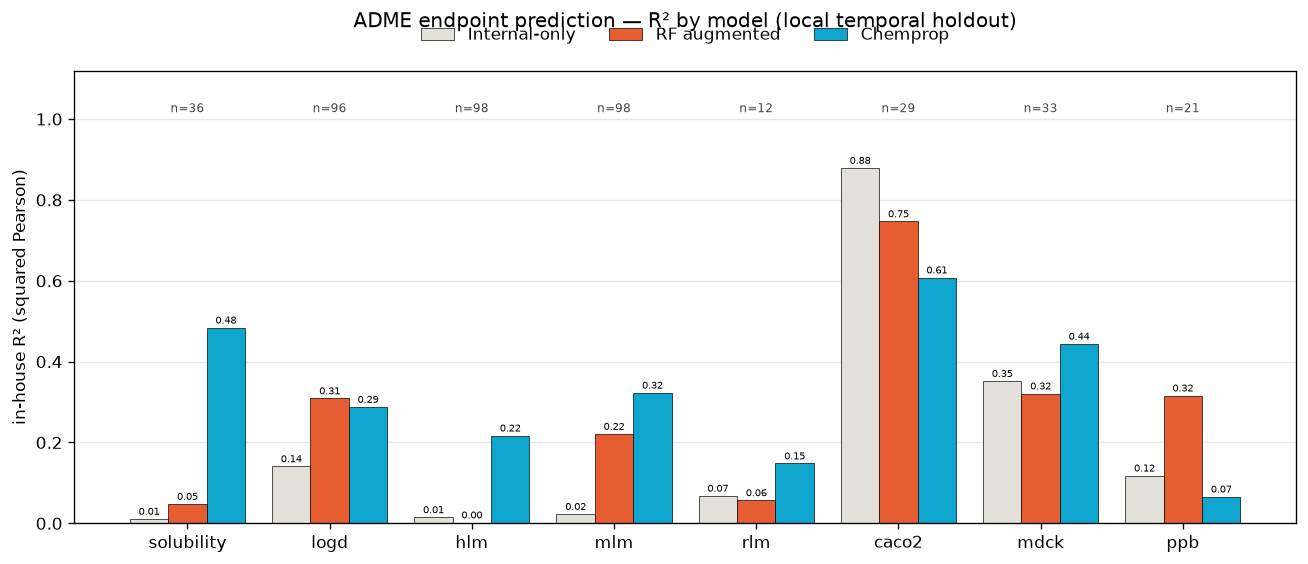

In [12]:
## plot results: grouped bar of in-house R2 per endpoint x model (temporal holdout)
import yaml
palette = yaml.safe_load(open('config/config.yaml'))['SERAC_C']
res = pd.read_csv('output/predictions_runs/summary_best_r2_rmse.csv')

groups = [('RFint_r2', 'Internal-only', palette['paper']),   # RF, internal compounds only
          ('RFaug_r2', 'RF augmented', palette['ember']),    # RF, internal + public
          ('CP_r2',    'Chemprop',     palette['azure'])]     # multitask D-MPNN (winning grouping)
x = np.arange(len(res)); w = 0.27

fig, ax = plt.subplots(figsize=(11, 4.8), dpi=120)
for i, (col, label, color) in enumerate(groups):
    bars = ax.bar(x + (i - 1) * w, res[col], w, label=label, color=color, edgecolor='black', linewidth=0.4)
    ax.bar_label(bars, fmt='%.2f', fontsize=6, padding=1)
for xi, n in zip(x, res['n']):                                # temporal test size (same for all 3 models)
    ax.text(xi, 1.01, f'n={int(n)}', ha='center', va='bottom', fontsize=7, color='#444')
ax.set_xticks(x); ax.set_xticklabels(res['endpoint'])
ax.set_ylabel('in-house R² (squared Pearson)'); ax.set_ylim(0, 1.12)
ax.set_title('ADME endpoint prediction — R² by model (local temporal holdout)', pad=26)
ax.legend(frameon=False, ncol=3, loc='upper center', bbox_to_anchor=(0.5, 1.13))
ax.grid(axis='y', alpha=0.3); ax.set_axisbelow(True)
plt.tight_layout(); plt.show()


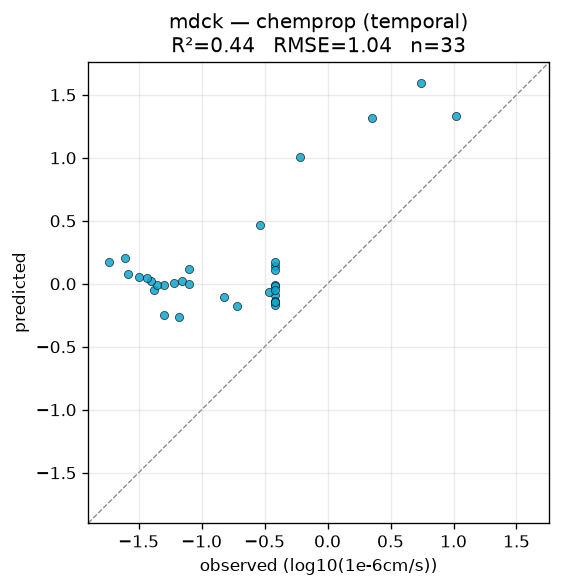

In [19]:
## plot parity plot for chosen endpoint and model:  (model: 'internal' | 'RF' | 'chemprop'; arm: 'temporal' | 'cv' | 'public_only')
ENDPOINT, MODEL, ARM = 'mdck', 'chemprop', 'temporal'   # <-- choose here

cfg = yaml.safe_load(open('config/config.yaml')); palette = cfg['SERAC_C']
CP_GRP = {'hlm': 'clearance', 'mlm': 'clearance', 'rlm': 'clearance'}          # else all8
COLOR = {'internal': palette['paper'], 'RF': palette['ember'], 'chemprop': palette['azure']}

def _munit(ep):
    c = cfg['ADME_ENDPOINTS'][ep]
    return {'identity': c['unit'], 'log10': f"log10({c['unit']})", 'logit_pct': 'logit(fu)'}.get(c['transform'], c['unit'])

def _pred_path(ep, model, arm):
    if model == 'internal':
        return f'output/predictions_runs/{ep}/pred_internal_{arm}.parquet'
    if model == 'RF':
        if arm == 'public_only':
            return f'output/predictions_runs/{ep}/pred_public_only.parquet'
        a = 'augmented_temporal_noADM' if (ep == 'caco2' and arm == 'temporal') else f'augmented_{arm}'
        return f'output/predictions_runs/{ep}/pred_{a}.parquet'
    grp = CP_GRP.get(ep, 'all8')                                                # chemprop winning grouping
    return f"output/predictions_runs_chemprop/{ep}/pred_{grp}_{ {'public_only':'publiconly'}.get(arm, arm) }.parquet"

def parity(ep, model, arm='temporal'):
    path = _pred_path(ep, model, arm)
    if not os.path.exists(path):
        print('not found:', path, '\navailable for', ep, ':')
        print(*[os.path.basename(p) for p in glob(f'output/predictions_runs*/{ep}/pred_*.parquet')], sep='\n')
        return
    d = pd.read_parquet(path).dropna(subset=['real_y', 'pred_y'])
    r2 = stats_tools.rsquared(d['real_y'], d['pred_y'])                         # in-house squared Pearson
    rmse = float(np.sqrt(((d['real_y'] - d['pred_y']) ** 2).mean()))
    lo, hi = min(d['real_y'].min(), d['pred_y'].min()), max(d['real_y'].max(), d['pred_y'].max())
    pad = 0.05 * (hi - lo); lo, hi = lo - pad, hi + pad
    fig, ax = plt.subplots(figsize=(5, 5), dpi=120)
    ax.plot([lo, hi], [lo, hi], '--', lw=0.8, c='#888', zorder=0)
    ax.scatter(d['real_y'], d['pred_y'], s=24, c=COLOR[model], edgecolor='black', linewidth=0.4, alpha=0.85)
    ax.set_xlim(lo, hi); ax.set_ylim(lo, hi); ax.set_aspect('equal')
    ax.set_xlabel(f'observed ({_munit(ep)})'); ax.set_ylabel('predicted')
    ax.set_title(f'{ep} — {model} ({arm})\nR²={r2:.2f}   RMSE={rmse:.2f}   n={len(d)}')
    ax.grid(alpha=0.25); ax.set_axisbelow(True); plt.tight_layout(); plt.show()

parity(ENDPOINT, MODEL, ARM)
